In [1]:
import nest
import os
import network
import addons
import helpers
import matplotlib.pyplot as plt
import numpy as np
from network_params import net_dict
import network_params
from sim_params import sim_dict
from stimulus_params import stim_dict


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Sep 26 2025 04:43:14

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



/home/hyc_1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning:Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.


In [2]:
dirs = os.listdir("data_background_rate_fig_1")
dirs = sorted(dirs)
#rates = np.linspace(5,20,len(dirs))
rates = np.zeros(len(dirs))

labels_rate = ["6 spikes/s", "9 spikes/s", "12 spikes/s", "18 spikes/s"]
names = [6,9,12,18]
pop_activity = np.zeros((len(dirs),4,25000))

freq_sample = 0.0002

for i in range(len(dirs)):
    name = "data_background_rate_fig_1/" + dirs[i] + "/trial_0/"
    for j in range(4):
        name_2 = name + "measurements/pop_activities2/pop_activity_" + str(j*2) + ".dat"
        pop_activity[i][j] = np.loadtxt(name_2)

In [3]:
dirs = os.listdir("data_background_rate_fig_1")
dirs = sorted(dirs)
#rates = np.linspace(5,20,len(dirs))
rates = np.zeros(len(dirs))

labels_rate = ["6 spikes/s", "9 spikes/s", "12 spikes/s", "18 spikes/s"]
neurons = {}
times = {}

for i in range(len(dirs)):
    name = "data_background_rate_fig_1/" + dirs[i] + "/trial_0/"
    neurons[i] = []
    times[i] = []
    sd_names, node_ids, data = helpers.__load_spike_times(name,"spike_recorder",addons.analysis_dict["analysis_start"], addons.analysis_dict["analysis_end"])
    last_node_id = node_ids[-1, -1]
    mod_node_ids = np.abs(node_ids - last_node_id) + 1
    for j, n in enumerate(sd_names):
        times[i].append(data[j]["time_ms"])
        neurons[i].append(np.abs(data[j]["sender"] - last_node_id) + 1)

/tmp/ipykernel_56967/2577444991.py:220: UserWarning:This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


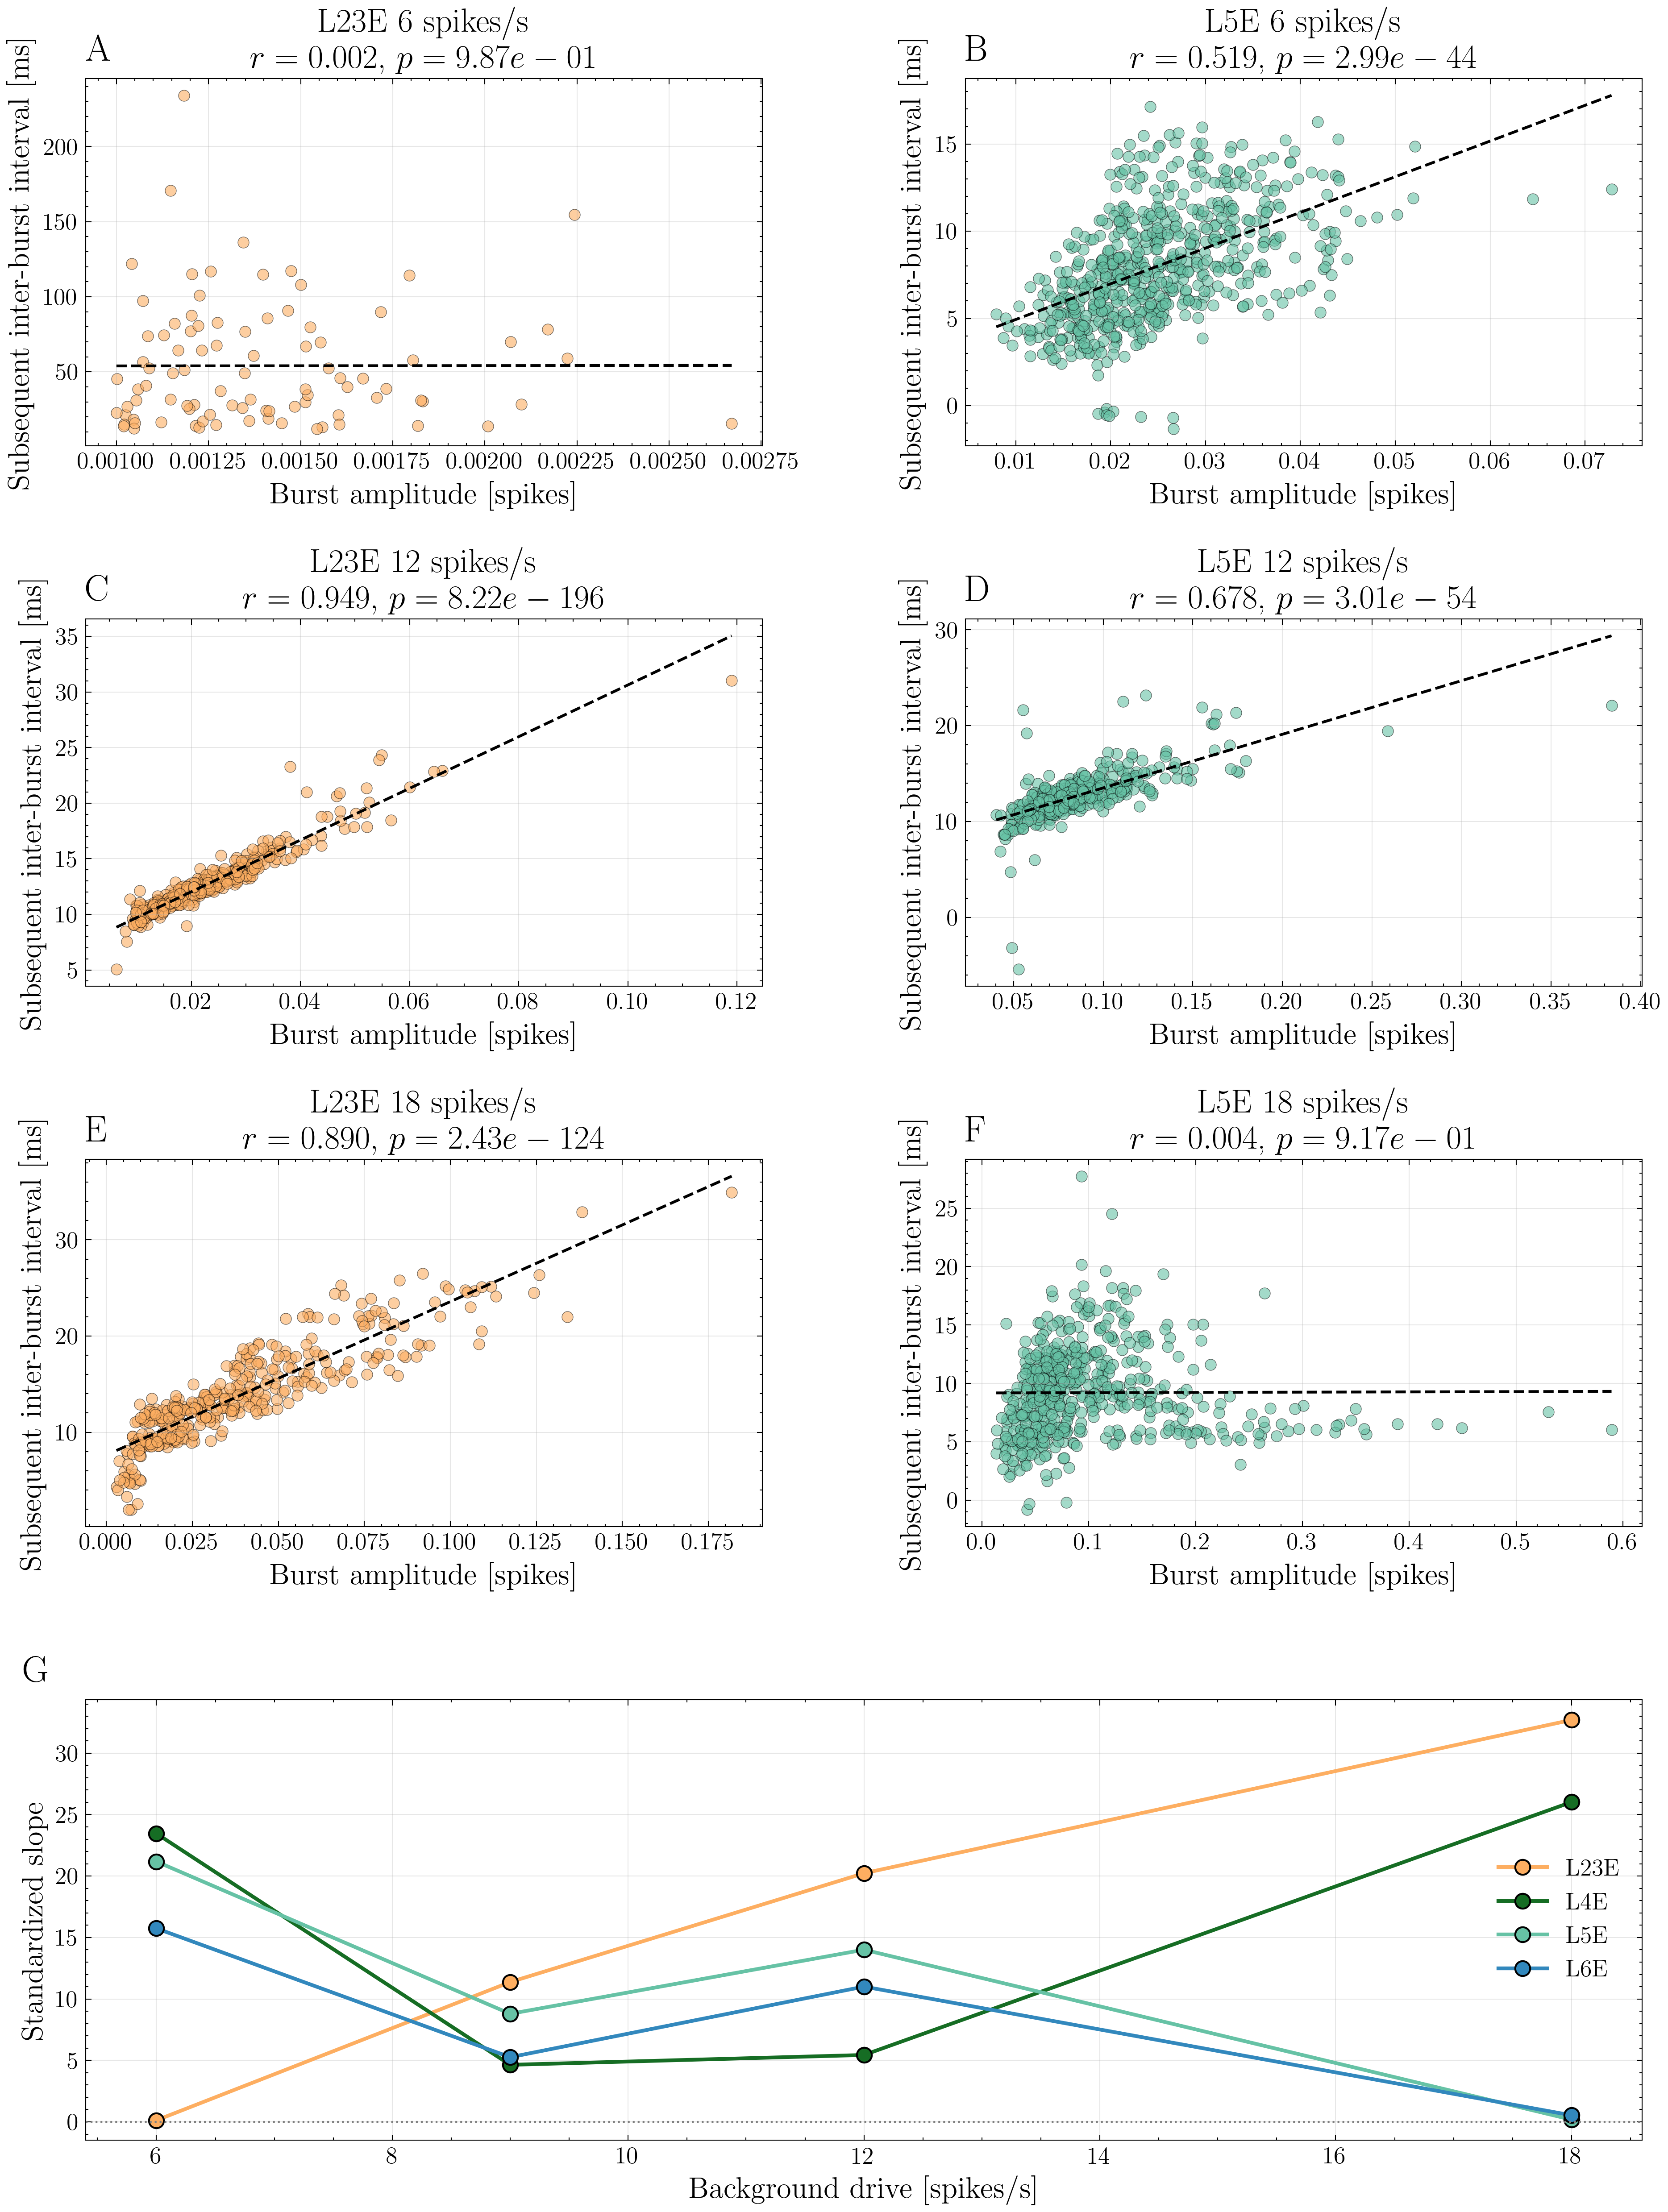

In [15]:
import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from scipy.signal import hilbert
from scipy.signal import find_peaks
from scipy.stats import pearsonr

bin_size = 15
peaks = {}
properties = {}
distances = {}
amplitudes = {}
bins = {}
bins_2 = {}

# NEW: raw (unpacked) storage for scatter/correlation
raw_amplitudes = {}   # amplitude of burst k
raw_distances  = {}   # interval *after* burst k  (i.e. distance to burst k+1)

distances_mean = np.zeros((len(pop_activity), len(pop_activity[0])))
amplitudes_mean = np.zeros((len(pop_activity), len(pop_activity[0])))
distances_std   = np.zeros((len(pop_activity), len(pop_activity[0])))
amplitudes_std  = np.zeros((len(pop_activity), len(pop_activity[0])))
bins_mean   = np.zeros((len(pop_activity), len(pop_activity[0]), bin_size+1))
bins_2_mean = np.zeros((len(pop_activity), len(pop_activity[0]), bin_size+1))
colors = ['#fdae61', "#166d24", '#66c2a5', '#3288bd']


inputs = ["6 spikes/s", "9 spikes/s", "12 spikes/s", "18 spikes/s"]
layers = ["L23E", "L4E", "L5E", "L6E"]

stp  = 5
plot = True
r_matrix     = np.full((len(layers), len(inputs)), np.nan)
p_matrix     = np.full((len(layers), len(inputs)), np.nan)
slope_matrix = np.full((len(layers), len(inputs)), np.nan)
std_slope_matrix = np.full((len(layers), len(inputs)), np.nan)
import string
from matplotlib.gridspec import GridSpec

fs_title = 18
fs_label = 16
fs_tick = 13
fs_letter = 20

fig = plt.figure(figsize=(15,20), dpi=300)

gs = GridSpec(
    4, 2,
    figure=fig,
    height_ratios=[1,1,1,1.2],
    hspace=0.45,
    wspace=0.30
)

scatter_axes = [
    fig.add_subplot(gs[0,0]),
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[1,0]),
    fig.add_subplot(gs[1,1]),
    fig.add_subplot(gs[2,0]),
    fig.add_subplot(gs[2,1])
]

panel = 0
for i in range(len(pop_activity)):
    peaks[i]      = {}
    properties[i] = {}
    distances[i]  = {}
    amplitudes[i] = {}
    bins[i]       = {}
    bins_2[i]     = {}
    raw_amplitudes[i] = {}
    raw_distances[i]  = {}

    for j in range(len(pop_activity[i])):
        peaks[i][j]      = {}
        properties[i][j] = {}
        distances[i][j]  = {}
        amplitudes[i][j] = {}
        bins[i][j]       = {}
        bins_2[i][j]     = {}

        test            = hilbert(pop_activity[i][j])
        test_amplitudes = np.abs(test)
        test_phases     = np.unwrap(np.angle(test))

        peaks[i][j], properties[i][j] = find_peaks(test_amplitudes, height=0.001, distance=20, width=3)

        # ── raw amplitude per burst ──────────────────────────────────────────
        amp_raw = test_amplitudes[peaks[i][j]]          # shape: (n_bursts,)
        # ── inter-burst intervals (distance from end of burst k to start of k+1)
        burst_distances = []
        for k in range(len(properties[i][j]['left_ips']) - 1):
            burst_distance = ((properties[i][j]['left_ips'][k+1] - properties[i][j]['right_ips'][k]) + properties[i][j]['widths'][k]) * 0.2
            burst_distances.append(burst_distance)
        # burst_distances has length  n_bursts - 1
        # pair amp of burst k  →  interval after burst k
        n_pairs = len(burst_distances)          # == n_bursts - 1
        raw_amplitudes[i][j] = amp_raw[:n_pairs]        # drop last burst (no interval after it)
        raw_distances[i][j]  = np.array(burst_distances)

        # ── Pearson correlation: amplitude vs subsequent interval ─────────────
        if n_pairs >= 2:
            r, p = pearsonr(raw_amplitudes[i][j], raw_distances[i][j])
        else:
            r, p = np.nan, np.nan

        if n_pairs >= 2:
            m,b = np.polyfit(raw_amplitudes[i][j], raw_distances[i][j],1)
            x = np.linspace(raw_amplitudes[i][j].min(),
                raw_amplitudes[i][j].max(),200)


        if j in [0,2] and i in [0,2,3]:

            ax = scatter_axes[panel]

            ax.scatter(raw_amplitudes[i][j],raw_distances[i][j],color=colors[j],alpha=0.6,edgecolors='k',linewidths=0.3)

            if n_pairs >= 2:
                ax.plot(x,m*x+b,'k--',lw=1.5)


            letter = string.ascii_uppercase[panel]

            ax.text(0.0,1.05,letter,transform=ax.transAxes,fontsize=fs_letter,fontweight='bold')

            ax.set_title(
                f"{layers[j]}    {inputs[i]}\n"
                f"$r={r:.3f}$, $p={p:.2e}$",
                fontsize=fs_title
            )

            ax.set_xlabel(
                "Burst amplitude [spikes]",
                fontsize=fs_label
            )

            ax.set_ylabel(
                "Subsequent inter-burst interval [ms]",
                fontsize=fs_label
            )

            ax.tick_params(labelsize=fs_tick)

            ax.grid(alpha=0.3)

            panel += 1
        r_matrix[j, i] = r
        p_matrix[j, i] = p

        if n_pairs >= 2:
            slope_matrix[j, i] = m
            std_slope_matrix[j, i] = (
            m * np.std(raw_amplitudes[i][j])
                    / np.mean(raw_distances[i][j]) * 100
                
            )
        # ── statistics & histograms (unchanged from your original) ───────────
        amplitudes_mean[j][i] = np.mean(amp_raw)
        amplitudes_std[j][i]  = np.std(amp_raw)

        amplitudes[i][j], bins[i][j] = np.histogram(amp_raw, bins=bin_size, density=False)

        distances_mean[j][i] = np.mean(burst_distances)
        distances_std[j][i]  = np.std(burst_distances)

        distances[i][j], bins_2[i][j] = np.histogram(
            burst_distances, bins=bin_size, density=False
        )

drive_rates = [int(s.split()[0]) for s in inputs]  # [6, 9, 12, 18]



ax = fig.add_subplot(gs[3,:])

for j in range(len(layers)):

    ax.plot(
        drive_rates,
        std_slope_matrix[j],
        'o-',
        color=colors[j],
        lw=2,
        ms=8,
        markeredgecolor='k',
        label=layers[j]
    )

ax.axhline(0,color='gray',ls=':')

ax.set_xlabel(
    "Background drive [spikes/s]",
    fontsize=16
)

ax.set_ylabel(
   r"Standardized slope",
    fontsize=16
)

ax.tick_params(labelsize=13)

ax.legend(fontsize=13)

ax.grid(alpha=0.3)

ax.text(
    -0.04,
    1.04,
    "G",
    transform=ax.transAxes,
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()
plt.show()